# Задание 7.3: Уравнение мелкой воды

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib.animation as anim
from IPython.display import HTML
from scipy.linalg import solve_banded

# Параметры

In [2]:
H = 1 # средняя высота
g = 1 # ускорение свободного падения
c = np.sqrt(g*H)
coef = 0.01 # понижающий коэф, чтобы проверить что нач скорость меньше c
print(f"C : {c}")

x0 = 0
x1 = 1
L = x1 - x0

t0 = 0 # нач момент
t1 = 0.3 # конечный момент

C : 1.0


## Параметры моделирования

In [3]:
Nx = 501 # кол-во вершин

dx = L/(Nx-1) # шаг по пространству
dt = 0.001 # шаг по времени

x = np.linspace(x0,x1,Nx)

# Параметры горба
x_center = x0 + L / 2  # Центр области
A = 0.01           # Амплитуда горба [м] (10% от H)
sigma = 0.2       # Ширина горба [м]

# Гауссов профиль
nu0 = A * np.exp(-((x - x_center)**2) / (2 * sigma**2))

# nu0 = np.sin(2*np.pi*x/L)
u0 = np.zeros_like(x)
condition = np.all( u0 < c*coef )
print(f"Условие малости скорости : {condition}")

Условие малости скорости : True


## Параметры анимации

In [4]:
anim_time = 5 # время на анимацию
fps = 20 # кол-во кадров в ссекунду

## Анимация

In [5]:
def anime( nu , u , x , fps , anim_time ):
    step = 1 + math.floor(len(u)/(fps*anim_time))
    nu = nu[::step,]
    u  = u[::step,]
    
    fig, ax = plt.subplots(nrows=2, ncols=1)
    
    line1, = ax[0].plot(x, nu[0], 'b-', linewidth=2)
    ax[0].set_xlim(0, L)
    ax[0].set_ylim(nu.min(), nu.max())
    ax[0].set_xlabel('X')
    ax[0].set_ylabel(f"\nu")
    ax[0].set_title(f'')
    ax[0].grid(True)

    line2, = ax[1].plot(x, u[0], 'b-', linewidth=2)
    ax[1].set_xlim(0, L)
    ax[1].set_ylim(u.min(), u.max())
    ax[1].set_xlabel('X')
    ax[1].set_ylabel('U')
    ax[1].set_title(f'')
    ax[1].grid(True)
    
    def update(frame):
        line1.set_ydata(nu[frame, :])
        line2.set_ydata(u[frame, :])
        return (line1 , line2)
    
    animt = anim.FuncAnimation(
        fig, 
        update, 
        frames=len(u),
        interval=1000/fps,  
        blit=True,
        repeat=True
    )
    
    plt.close()
    return HTML(animt.to_jshtml())

## Схема Лакса-Фридрихса

In [6]:
def lax_fridrihs( nu0 , u0 , g , H , dt , dx , t0 , t1 ):
    Nx = len(nu0)
    Nt = math.floor((t1-t0)/dt) #кол-во шагов равных dt
    dt_last = t1 - t0 - Nt*dt # последний шаг, который может быть меньше, так как надо точно попасть в t1

    t = np.linspace(t0,t1,Nt+1)
    if math.fabs(dt_last) > 1.e-8:
        t.append(t1)

    if math.fabs(dt_last) > 1.e-8:
        nu = np.zeros( ( 1+Nt+1 , Nx ) )
        u = np.zeros( ( 1+Nt+1 , Nx ) )
    else:
        nu = np.zeros( ( 1+Nt , Nx ) )
        u  = np.zeros( ( 1+Nt , Nx ) )

    nu[0] = nu0
    u[0] = u0

    for j in range(0,Nt):
        nu_l = np.roll( nu[j] , 1 )
        nu_r = np.roll( nu[j] ,-1 )
        u_l  = np.roll( u[j]  , 1 )
        u_r  = np.roll( u[j]  ,-1 )
        nu[j+1] = ( nu_r + nu_l )/2 - H*dt*(u_r - u_l)/(2*dx)
        u[j+1]  = ( u_r + u_l )/2 - g*dt*(nu_r - nu_l)/(2*dx)

    if math.fabs(dt_last) > 1.e-8:
        j = Nt
        nu_l = np.roll( nu[j] , 1 )
        nu_r = np.roll( nu[j] ,-1 )
        u_l  = np.roll( u[j]  , 1 )
        u_r  = np.roll( u[j]  ,-1 )
        nu[j+1] = ( nu_r + nu_l )/2 - H*dt*(u_r - u_l)/(2*dx)
        u[j+1]  = ( u_r + u_l )/2 - g*dt*(nu_r - nu_l)/(2*dx)
    return (nu , u , t)

# Зелёный уровень

## Вычисление

In [7]:
nu , u , t = lax_fridrihs( nu0 , u0 , g , H , dt , dx , t0 , t1 )

anime(nu,u,x,fps,anim_time)

# Жёлтый уровень

## Схема Лакса-Вендрофа

In [8]:
def flux( u , g ):
    h = u[0]
    hu = u[1]
    if h <= 1e-10:  # Защита от деления на ноль
        u = 0
    else:
        u = hu / h
    return np.array( [ hu , hu*u + g*h**2/2 ] )

def lax_wend_step( U , g , dt , dx ):
    U_half = np.zeros_like(U)
    Fl = np.array([ flux(u,g) for u in U ])
    U_next = np.roll(U,-1,axis=0)
    Fr = np.array([ flux(u,g) for u in U_next ])

    U_half = 0.5*( U + U_next ) - 0.5*dt/dx*( Fr - Fl )

    Fr_half = np.array([ flux(u,g) for u in U_half ])
    U_half_prev = np.roll(U_half,1,axis=0)
    Fl_half = np.array([ flux(u,g) for u in U_half_prev ])

    U_new = U - dt/dx*( Fr_half - Fl_half )
    U_new[0] = U[1]
    U_new[-1] = U[-2]

    return U_new

def lax_wend( h0 , u0 , g , dx , t0 , t1 , cfl = 0.5 ):
    U0 = np.zeros((len(h0),2))
    U0[:,0] = h0
    U0[:,1] = h0*u0

    U = [U0]
    t = [t0]
    U_half_hist = []

    dt = 0.0001

    while t[-1] < t1:

        h = U[-1][:,0]
        u = U[-1][:,1] / np.maximum(h, 1e-10)
        c = np.sqrt(g * h)
        max_speed = np.max(np.abs(u) + c)
        dt_adaptive = cfl * dx / max_speed if max_speed > 0 else dt

        if t[-1] + dt_adaptive > t1:
            dt_adaptive = t1 - t[-1]
        U_new = lax_wend_step(U[-1],g,dt_adaptive,dx)
        U.append( U_new )
        t.append(t[-1]+dt_adaptive)
    return (np.array(U) , t )

## Моделирование задачи о распаде разрыва

In [9]:
hl = 2 # высота столба слева
hr = 1 # высота столба справа

h0 = np.zeros_like(x) + hr
h0[:math.ceil(len(h0)/2)] = np.ones( math.ceil(len(h0)/2) ) * hl

u0 = np.zeros_like(x)

u,tst = lax_wend( h0 , u0 , g , dx , t0 , t1 )


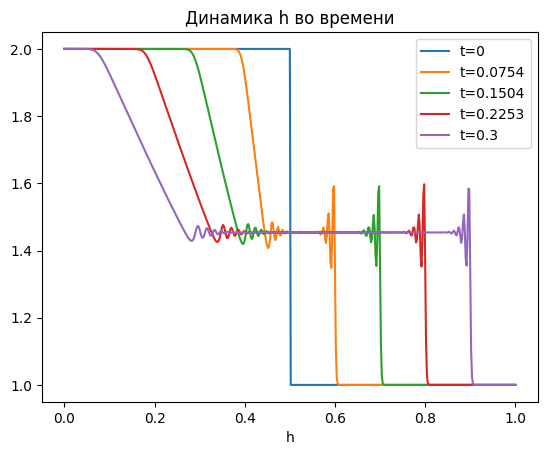

In [10]:
n_graf = 5 # кол-во нарисуемых графиков ( > 1 )

ind = [ math.ceil( i*(len(u)-1)/(n_graf-1) ) for i in range(n_graf) ]

for i in ind:
    plt.plot( x , u[i,:,0] , label = f"t={round(tst[i],4)}" )
plt.xlabel("X")
plt.xlabel("h")
plt.title("Динамика h во времени")
plt.legend()
plt.show()

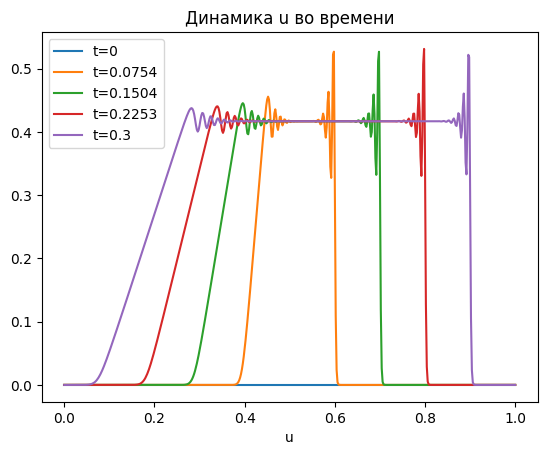

In [11]:
n_graf = 5 # кол-во нарисуемых графиков ( > 1 )

ind = [ math.ceil( i*(len(u)-1)/(n_graf-1) ) for i in range(n_graf) ]

for i in ind:
    plt.plot( x , u[i,:,1]/u[i,:,0] , label = f"t={round(tst[i],4)}" )
plt.xlabel("X")
plt.xlabel("u")
plt.title("Динамика u во времени")
plt.legend()
plt.show()